In [1]:
cd /Users/vladkorsikov/research/dataset/glioma_raw

/Users/vladkorsikov/research/dataset/glioma_raw


In [2]:
import os
import numpy as np
import math
from time import time
from PIL import Image
import cv2
from matplotlib import pyplot as plt

In [3]:

path, dirs, files = next(os.walk("/Users/vladkorsikov/research/dataset_main/2_glioma_resize"))
glioma_count = len(files)-1

path, dirs, files = next(os.walk("/Users/vladkorsikov/research/dataset_main/2_meningioma_resize"))
meningioma_count = len(files)-1

path, dirs, files = next(os.walk("/Users/vladkorsikov/research/dataset_main/2_pituitary_resize"))
pituitary_count = len(files)-1

path, dirs, files = next(os.walk("/Users/vladkorsikov/research/dataset_main/2_test_resize"))
test_count = len(files)-1

glioma_image_numbers = []
glioma_save_image_numbers = []
meningioma_image_numbers = []
meningioma_save_image_numbers = []
pituitary_image_numbers = []
pituitary_save_image_numbers = []
test_image_numbers = []
test_save_image_numbers = []

#Местонахождение папок
path_glioma = '/Users/vladkorsikov/research/dataset_main/2_glioma_resize'
path_glioma_save = '/Users/vladkorsikov/research/dataset_main/3_glioma_centered'
path_meningioma = '/Users/vladkorsikov/research/dataset_main/2_meningioma_resize'
path_meningioma_save = '/Users/vladkorsikov/research/dataset_main/3_meningioma_centered'
path_pituitary = '/Users/vladkorsikov/research/dataset_main/2_pituitary_resize'
path_pituitary_save = '/Users/vladkorsikov/research/dataset_main/3_pituitary_centered'
path_test = '/Users/vladkorsikov/research/dataset_main/2_test_resize'
path_test_save = '/Users/vladkorsikov/research/dataset_main/3_test_centered'

#заполняем списки имен
count = 0
for i in range(glioma_count):
  count += 1
  image_name = f'{path_glioma}/glioma{str(count)}.png'
  glioma_image_numbers.append(image_name)
  image_save_name = f'{path_glioma_save}/glioma{str(count)}.png'
  glioma_save_image_numbers.append(image_save_name)


count = 0
for i in range(meningioma_count):
  count += 1
  image_name = f'{path_meningioma}/meningioma{str(count)}.png'
  meningioma_image_numbers.append(image_name)
  image_save_name = f'{path_meningioma_save}/meningioma{str(count)}.png'
  meningioma_save_image_numbers.append(image_save_name)

count = 0
for i in range(pituitary_count):
  count += 1
  image_name = f'{path_pituitary}/pituitary{str(count)}.png'
  pituitary_image_numbers.append(image_name)
  image_save_name = f'{path_pituitary_save}/pituitary{str(count)}.png'
  pituitary_save_image_numbers.append(image_save_name)

count = 0
for i in range(test_count):
  count += 1
  image_name = f'{path_test}/test{str(count)}.png'
  test_image_numbers.append(image_name)
  image_save_name = f'{path_test_save}/test{str(count)}.png'
  test_save_image_numbers.append(image_save_name)

print(len(glioma_image_numbers))
print(len(meningioma_image_numbers))
print(len(pituitary_image_numbers))
print(len(test_image_numbers))
print(glioma_image_numbers[0])
print(glioma_image_numbers[-1])

print(glioma_save_image_numbers[-1])

print(test_image_numbers[0])
print(test_image_numbers[-1])
print(test_save_image_numbers[-1])

200
200
200
75
/Users/vladkorsikov/research/dataset_main/2_glioma_resize/glioma1.png
/Users/vladkorsikov/research/dataset_main/2_glioma_resize/glioma200.png
/Users/vladkorsikov/research/dataset_main/3_glioma_centered/glioma200.png
/Users/vladkorsikov/research/dataset_main/2_test_resize/test1.png
/Users/vladkorsikov/research/dataset_main/2_test_resize/test75.png
/Users/vladkorsikov/research/dataset_main/3_test_centered/test75.png


In [4]:
#Берём тестовое изображение, чтобы получить его полезные признаки
road_1 = glioma_image_numbers[-1]

img_brain = cv2.imread(road_1) #, cv2.IMREAD_GRAYSCALE)
img_brain_grey = cv2.imread(road_1, cv2.IMREAD_GRAYSCALE)


image_length = len(img_brain_grey)
image_width = len(img_brain_grey[0])

#Задаём функцию нормализации, возвращает набор строк, из которых состоит ЦВЕТНОЕ изображение
def normalization_colour(img_brain_grey, img_brain, image_width):
  image_list_2 = []
  image_list_3 = []
  for line, line_2 in zip(img_brain_grey, img_brain):
    list_for_image = []
    list_for_image_2 = []
    for pixel_number in range(image_width):
      a = line[pixel_number]
      b = line_2[pixel_number]
      if a<10:
        a=1
        b=[0, 0, 0]
      else:
        a=a
        b=b
      list_for_image.append(a)
      list_for_image_2.append(b)
    image_list_2.append(list_for_image)
    image_list_3.append(list_for_image_2)
  return image_list_3

#Задаём функцию нормализации, возвращает набор строк, из которых состоит СЕРОЕ изображение
def normalization_grey(img_brain_grey, img_brain, image_width):
  image_list_2 = []
  image_list_3 = []
  for line, line_2 in zip(img_brain_grey, img_brain):
    list_for_image = []
    list_for_image_2 = []
    for pixel_number in range(image_width):
      a = line[pixel_number]
      b = line_2[pixel_number]
      if a<10:
        a=1
        b=[0, 0, 0]
      else:
        a=a
        b=b
      list_for_image.append(a)
      list_for_image_2.append(b)
    image_list_2.append(list_for_image)
    image_list_3.append(list_for_image_2)
  return image_list_2

test_1 =  normalization_colour(img_brain_grey, img_brain, image_width)
test_2 = normalization_grey(img_brain_grey, img_brain, image_width)

test_1_1 = np.array(test_1)
test_2_1 = np.array(test_2)

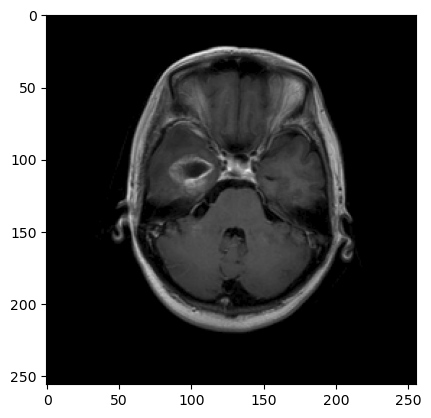

In [5]:
plt.imshow (test_1_1)

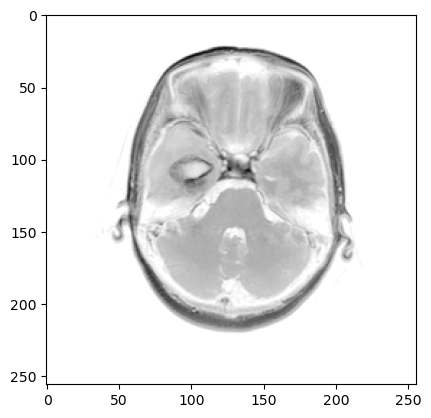

In [6]:
plt.imshow (test_2_1, cmap=plt.cm.binary)

In [7]:
def find_horizontal_delta(image_grey, image_width):
  image_width_2 = int(image_width*2)
  horizontal_top = 0
  for line in range(image_length):
    pixel_sum=0
    for pixel in image_grey[line]:
      pixel_sum += pixel
    if pixel_sum <=image_width_2:
      horizontal_top +=1
    else:
      break
  horizontal_bottom = 0
  for line in range(image_length):
    pixel_sum=0
    for pixel in image_grey[-line]:
      pixel_sum += pixel
    if pixel_sum <=image_width_2:
      horizontal_bottom +=1
    else:
      break
  horizontal_delta = int((horizontal_top - horizontal_bottom)/2)
  return horizontal_delta

test_3_hor_delta = find_horizontal_delta(test_2, image_width)
print(test_3_hor_delta)

-7


In [8]:
def image_correction_top_and_bottom(image_list_4, horizontal_delta):

  if horizontal_delta > 1:
    for i in range(horizontal_delta):
      line_to_replace = image_list_4.pop(0)
      image_list_4.append(line_to_replace)
  elif horizontal_delta < -1:
    for i in range(abs(horizontal_delta)):
      line_to_replace = image_list_4.pop(-1)
      image_list_4.insert(0, line_to_replace)
  return image_list_4

test_4 = image_correction_top_and_bottom(test_1, test_3_hor_delta)
test_4_1 = np.array(test_4)

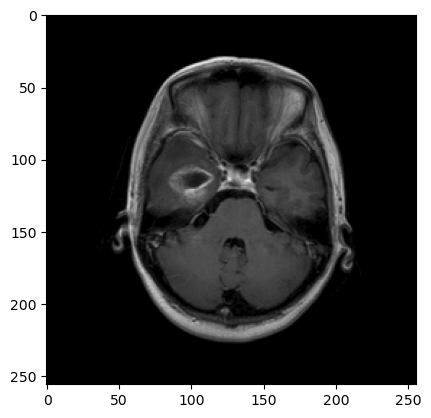

In [9]:
plt.imshow (test_4_1)

In [10]:
#Сделаем то же самое для полос слева и справа

def find_vertical_delta(image_grey, image_length):
  image_length_2 = int(image_length*2)
  vertical_left = 0
  for number in range(image_width):
    vertical_sum=0
    for line in image_grey:
      vertical_sum += line[number]
    if vertical_sum <=image_length_2:
      vertical_left +=1
    else:
      break
  vertical_right = 0
  for number in range(image_width):
    vertical_sum=0
    for line in image_grey:
      vertical_sum += line[-number]
    if vertical_sum <=image_length_2:
      vertical_right +=1
    else:
      break
  vertical_delta = int((vertical_left - vertical_right)/2)
  return vertical_delta


test_5_vert_delta = find_vertical_delta(test_2, image_length)
print(test_5_vert_delta)

1


In [11]:
# осталось реализовать метод для корректировки изображения по вертикали
def image_correction_left_and_right(image_list_5, vertical_delta):
  image_list_6 = []
  if vertical_delta > 1:
    for i in range(vertical_delta):
      for line in image_list_5:
        removable_pixel = line.pop(0)
        line.append(removable_pixel)
        image_list_6.append(line)
      image_list_5 = image_list_6.copy()
      image_list_6 = []
  elif vertical_delta < 1:
    for i in range(abs(vertical_delta)):
      for line in image_list_5:
        removable_pixel = line.pop(-1)
        line.insert(0, removable_pixel)
        image_list_6.append(line)
      image_list_5 = image_list_6.copy()
      image_list_6 = []
  image_colour_vert = np.array(image_list_5)
  return image_colour_vert

test_7 = image_correction_left_and_right(test_4, test_5_vert_delta)

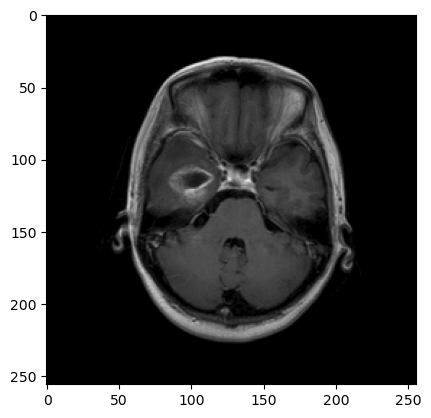

In [12]:
plt.imshow (test_7)

In [13]:
for road_2, road_save_2 in zip(glioma_image_numbers, glioma_save_image_numbers):
  img_brain_2 = cv2.imread(road_2)
  img_brain_grey_2 = cv2.imread(road_2, cv2.IMREAD_GRAYSCALE)
  image_length = len(img_brain_grey_2)
  image_width = len(img_brain_grey_2[0])
  img_brain_3 = normalization_colour(img_brain_grey_2, img_brain_2, image_width)
  img_brain_grey_3 = normalization_grey(img_brain_grey_2, img_brain_2, image_width)
  horizontal_delta = find_horizontal_delta(img_brain_grey_3, image_width)
  img_brain_4 = image_correction_top_and_bottom(img_brain_3, horizontal_delta)
  vertical_delta = find_vertical_delta(img_brain_grey_3, image_length)
  img_brain_final = image_correction_left_and_right(img_brain_4, vertical_delta)
  cv2.imwrite(road_save_2, img_brain_final)

print('glioma ready')

glioma ready


In [14]:
for road_2, road_save_2 in zip(meningioma_image_numbers, meningioma_save_image_numbers):
  img_brain_2 = cv2.imread(road_2)
  img_brain_grey_2 = cv2.imread(road_2, cv2.IMREAD_GRAYSCALE)
  image_length = len(img_brain_grey_2)
  image_width = len(img_brain_grey_2[0])
  img_brain_3 = normalization_colour(img_brain_grey_2, img_brain_2, image_width)
  img_brain_grey_3 = normalization_grey(img_brain_grey_2, img_brain_2, image_width)
  horizontal_delta = find_horizontal_delta(img_brain_grey_3, image_width)
  img_brain_4 = image_correction_top_and_bottom(img_brain_3, horizontal_delta)
  vertical_delta = find_vertical_delta(img_brain_grey_3, image_length)
  img_brain_final = image_correction_left_and_right(img_brain_4, vertical_delta)
  cv2.imwrite(road_save_2, img_brain_final)

print('meningioma ready')

meningioma ready


In [15]:
for road_2, road_save_2 in zip(pituitary_image_numbers, pituitary_save_image_numbers):
  img_brain_2 = cv2.imread(road_2)
  img_brain_grey_2 = cv2.imread(road_2, cv2.IMREAD_GRAYSCALE)
  image_length = len(img_brain_grey_2)
  image_width = len(img_brain_grey_2[0])
  img_brain_3 = normalization_colour(img_brain_grey_2, img_brain_2, image_width)
  img_brain_grey_3 = normalization_grey(img_brain_grey_2, img_brain_2, image_width)
  horizontal_delta = find_horizontal_delta(img_brain_grey_3, image_width)
  img_brain_4 = image_correction_top_and_bottom(img_brain_3, horizontal_delta)
  vertical_delta = find_vertical_delta(img_brain_grey_3, image_length)
  img_brain_final = image_correction_left_and_right(img_brain_4, vertical_delta)
  cv2.imwrite(road_save_2, img_brain_final)

print('pituitary ready')

pituitary ready


In [16]:
for road_2, road_save_2 in zip(test_image_numbers, test_save_image_numbers):
  img_brain_2 = cv2.imread(road_2)
  img_brain_grey_2 = cv2.imread(road_2, cv2.IMREAD_GRAYSCALE)
  image_length = len(img_brain_grey_2)
  image_width = len(img_brain_grey_2[0])
  img_brain_3 = normalization_colour(img_brain_grey_2, img_brain_2, image_width)
  img_brain_grey_3 = normalization_grey(img_brain_grey_2, img_brain_2, image_width)
  horizontal_delta = find_horizontal_delta(img_brain_grey_3, image_width)
  img_brain_4 = image_correction_top_and_bottom(img_brain_3, horizontal_delta)
  vertical_delta = find_vertical_delta(img_brain_grey_3, image_length)
  img_brain_final = image_correction_left_and_right(img_brain_4, vertical_delta)
  cv2.imwrite(road_save_2, img_brain_final)

print('test ready')

test ready
